# Computer Vision — JPEG AI vs Deepfake Detection

Notebook principale del progetto.

## ⚙️ Setup — eseguire SOLO questa cella a ogni avvio del runtime

Monta Drive, installa le dipendenze e carica il detector pre-addestrato (Veritas). I pesi vengono messi in cache su Drive: si scaricano da Kaggle solo la prima volta.

In [2]:
# ====================================================================
# SETUP — unica cella da eseguire a ogni avvio
# ====================================================================
import os, sys, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import OrderedDict
from PIL import Image

# 1) Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) Dipendenze del detector (facenet con --no-deps per evitare il pin di Pillow)
!{sys.executable} -m pip install -q --no-deps facenet-pytorch
!{sys.executable} -m pip install -q pywavelets
import pywt
from facenet_pytorch import MTCNN

# 3) Percorsi e parametri globali
device       = 'cuda' if torch.cuda.is_available() else 'cpu'
DATASET_PATH = '/content/drive/MyDrive/Deepfake_Dataset'        # dataset compresso (su Drive)
WEIGHTS      = '/content/drive/MyDrive/best_veritas_model.pth'  # pesi detector (cache su Drive)
BPP_LIST     = [0.12, 0.25, 0.50, 0.75]

# 4) Pesi Veritas: scarica da Kaggle SOLO la prima volta, poi restano su Drive
if not os.path.exists(WEIGHTS):
    from getpass import getpass
    if 'KAGGLE_API_TOKEN' not in os.environ:
        tok = getpass('Kaggle API token (KGAT_...): ').strip()
        os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
        with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as fh:
            fh.write(tok)
        os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)
        os.environ['KAGGLE_API_TOKEN'] = tok
    !{sys.executable} -m pip install -q -U kaggle
    !kaggle kernels output sandeepkumargond01/deepfake -p /content/veritas
    shutil.copy('/content/veritas/best_veritas_model.pth', WEIGHTS)
    print('Pesi copiati su Drive.')

# 5) Architettura del detector (Veritas / CompressionAwareHybrid)
class CWA(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(ch, ch // 2, bias=False), nn.ReLU(),
                                nn.Linear(ch // 2, ch, bias=False), nn.Sigmoid())
    def forward(self, x):
        b, c, _, _ = x.size()
        return x * self.fc(self.gap(x).view(b, c)).view(b, c, 1, 1).expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, 1); self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1); self.bn2 = nn.BatchNorm2d(out_c)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(nn.Conv2d(in_c, out_c, 1, stride), nn.BatchNorm2d(out_c))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out)); out += self.shortcut(x)
        return F.relu(out)

class CompressionAwareHybrid(nn.Module):
    def __init__(self):
        super().__init__()
        self.spatial = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2))
        self.cwa_spatial = CWA(128)
        self.wavelet = nn.Sequential(
            nn.Conv2d(9, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2))
        self.cwa_wavelet = CWA(64)
        self.align = nn.Conv2d(64, 128, 1)
        self.entry = nn.Sequential(nn.Conv2d(256, 64, 7, stride=2, padding=3), nn.BatchNorm2d(64),
                                   nn.ReLU(), nn.MaxPool2d(3, stride=2, padding=1))
        self.middle = nn.Sequential(ResBlock(64, 128, 2), ResBlock(128, 256, 2))
        self.exit = nn.Sequential(nn.Conv2d(256, 128, 1), nn.BatchNorm2d(128), nn.ReLU(),
                                  nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, 2))
    def forward(self, img, wav):
        s = self.cwa_spatial(self.spatial(img))
        w = self.cwa_wavelet(self.wavelet(wav))
        w = F.interpolate(self.align(w), size=s.shape[2:])
        return self.exit(self.middle(self.entry(torch.cat([s, w], dim=1))))

# 6) MTCNN + carica i pesi
mtcnn = MTCNN(image_size=64, margin=14, keep_all=False, post_process=False, device=device)
vmodel = CompressionAwareHybrid().to(device)
_sd = torch.load(WEIGHTS, map_location=device)
_sd = OrderedDict((k[7:] if k.startswith('module.') else k, v) for k, v in _sd.items())
vmodel.load_state_dict(_sd); vmodel.eval()

# 7) Predizione fedele: face MTCNN [0,255] + wavelet db2 (niente normalizzazione)
@torch.no_grad()
def veritas_predict(path):
    face = mtcnn(Image.open(path).convert('RGB'))
    if face is None:
        return None
    face = face.cpu()
    fnp = face.permute(1, 2, 0).numpy()
    wav = []
    for c in range(3):
        _, (LH, HL, HH) = pywt.dwt2(fnp[:, :, c], 'db2')
        wav += [LH, HL, HH]
    wav_t = torch.tensor(np.stack(wav, 0)).float().unsqueeze(0).to(device)
    face_t = face.float().unsqueeze(0).to(device)
    return torch.softmax(vmodel(face_t, wav_t), 1)[0].cpu().numpy()   # [p_real, p_fake]

print('Setup completo. veritas_predict() pronto. device =', device)
print('DATASET_PATH =', DATASET_PATH)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.3 MB/s eta 0:00:00
Setup completo. veritas_predict() pronto. device = cpu
DATASET_PATH = /content/drive/MyDrive/Deepfake_Dataset


## 📊 Valutazione — degradation curve (Obiettivo 1)

Legge il dataset compresso da Drive e calcola l'AUC del detector su `original` e a ogni livello di bpp. Metrica = **AUC** (indipendente dalla soglia, standard per deepfake detection).

CONDIZIONE     AUC     CI95              n
original      0.722   [0.578, 0.848]   50
bpp0.12       0.675   [0.515, 0.811]   50
bpp0.25       0.712   [0.561, 0.839]   50
bpp0.5        0.688   [0.537, 0.824]   50
bpp0.75       0.693   [0.542, 0.828]   50


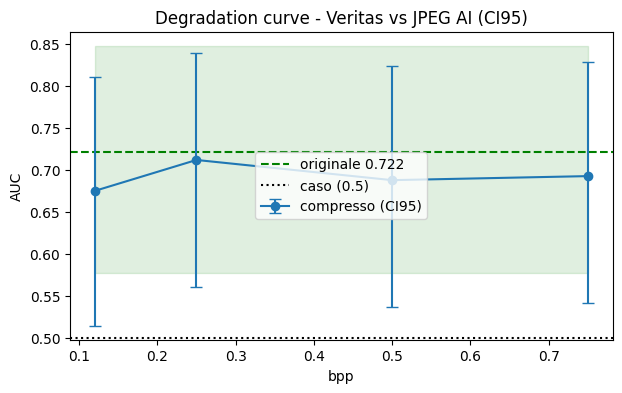

In [24]:
# Degradation curve: AUC + CI95 bootstrap
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

def scores_for_condition(suffix):
    scores, labels = [], []
    for cls, label in [('real', 0), ('fake', 1)]:
        d = os.path.join(DATASET_PATH, f'{cls}_{suffix}')
        if not os.path.isdir(d):
            continue
        for f in sorted(os.listdir(d)):
            pr = veritas_predict(os.path.join(d, f))
            if pr is None:
                continue
            scores.append(float(pr[1])); labels.append(label)
    return np.array(labels), np.array(scores)

def auc_with_ci(labels, scores, n_boot=2000, seed=0):
    if len(set(labels.tolist())) < 2:
        return None, None, None
    auc = roc_auc_score(labels, scores)
    rng = np.random.default_rng(seed)
    n = len(labels); boots = []
    for _ in range(n_boot):
        s = rng.integers(0, n, n)
        if len(set(labels[s].tolist())) < 2:
            continue
        boots.append(roc_auc_score(labels[s], scores[s]))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return auc, lo, hi

conds = ['original'] + [f'bpp{b}' for b in BPP_LIST]
res = []
print('CONDIZIONE     AUC     CI95              n')
for suf in conds:
    labels, scores = scores_for_condition(suf)
    auc, lo, hi = auc_with_ci(labels, scores)
    res.append((auc, lo, hi))
    print(f'{suf:12s}  {auc:.3f}   [{lo:.3f}, {hi:.3f}]   {len(labels)}')

o = res[0]; comp = res[1:]
aucs = [r[0] for r in comp]
yerr = [[r[0]-r[1] for r in comp], [r[2]-r[0] for r in comp]]
plt.figure(figsize=(7,4))
plt.axhline(o[0], color='g', ls='--', label=f'originale {o[0]:.3f}')
plt.fill_between([min(BPP_LIST), max(BPP_LIST)], o[1], o[2], color='g', alpha=0.12)
plt.errorbar(BPP_LIST, aucs, yerr=yerr, fmt='o-', capsize=4, label='compresso (CI95)')
plt.axhline(0.5, color='k', ls=':', label='caso (0.5)')
plt.xlabel('bpp'); plt.ylabel('AUC')
plt.title('Degradation curve - Veritas vs JPEG AI (CI95)')
plt.legend(); plt.show()

---
## 🛠️ Generazione dataset compresso — *opzionale*

Eseguire **solo** per creare o ampliare il dataset compresso. È la parte pesante (build di JPEG AI ~20-40 min + download FF++). Una volta che il dataset è su Drive, per i test basta la cella di **Setup**.

Ordine: setup JPEG AI → download FF++ → funzioni → genera.

In [5]:
# === Setup JPEG AI reference software (SOLO per comprimere; lento) ===
import os

if not os.path.exists('/content/miniconda/bin/conda'):
    !wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /content/miniconda.sh
    !bash /content/miniconda.sh -b -p /content/miniconda
os.environ['PATH'] = '/content/miniconda/bin:' + os.environ['PATH']
os.environ.pop('PYTHONPATH', None)
!conda --version

# Accetta i Terms of Service dei canali conda (altrimenti 'conda create' fallisce)
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

!apt-get -qq install -y git-lfs doxygen graphviz
!git lfs install

%cd /content
if not os.path.isdir('/content/jpeg-ai-reference-software'):
    !git clone https://gitlab.com/wg1/jpeg-ai/jpeg-ai-reference-software.git
%cd /content/jpeg-ai-reference-software
!git lfs fetch
!git lfs checkout
!make setup_env

!conda env list | grep jpeg_ai_vm || echo 'env jpeg_ai_vm NON creato'
print('Setup JPEG AI terminato.')

PREFIX=/content/miniconda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /content/miniconda
conda 26.3.2
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Selecting previously unselected package libllvm14:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../0-libllvm14_1%3a14.0.0-1ubuntu1.1_amd64.deb ...
Unpacking libllvm14:amd64 (1:14.0.0-1ubuntu1.1) ...
Selecting previously unselected package libclang-cpp1

In [ ]:
# === Scarica FaceForensics++ (frame estratti, c23) da Kaggle ===
import os
from getpass import getpass

if not os.path.isdir('/content/ff/FF++C32-Frames'):
    if 'KAGGLE_API_TOKEN' not in os.environ:
        tok = getpass('Kaggle API token (KGAT_...): ').strip()
        os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
        with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as fh:
            fh.write(tok)
        os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)
        os.environ['KAGGLE_API_TOKEN'] = tok
    !pip -q install -U kaggle
    !kaggle datasets download -d fatimahirshad/faceforensics-extracted-dataset-c23 -p /content/ff --unzip

!ls /content/ff/FF++C32-Frames

In [3]:
# Funzioni: costruzione split (paired) + compressione JPEG AI (encoder con -r, 1 processo/img)
import os, random, subprocess, tempfile
from PIL import Image

VALID_IMG_EXT = ('.png', '.jpg', '.jpeg', '.bmp')

def _list_images(root):
    out = []
    for dp, _, fs in os.walk(root):
        out += [os.path.join(dp, f) for f in fs if f.lower().endswith(VALID_IMG_EXT)]
    return sorted(out)

def _save_rgb_png(src, dst):
    try:
        Image.open(src).convert('RGB').save(dst); return True
    except Exception as e:
        print('skip', src, e); return False

def build_original_split(real_src, fake_src, dataset_path, n_per_class=None, seed=42):
    real, fake = _list_images(real_src), _list_images(fake_src)
    idx = list(range(min(len(real), len(fake)))); random.Random(seed).shuffle(idx)
    if n_per_class is not None:
        idx = idx[:n_per_class]
    ro = os.path.join(dataset_path, 'real_original'); fo = os.path.join(dataset_path, 'fake_original')
    os.makedirs(ro, exist_ok=True); os.makedirs(fo, exist_ok=True)
    n = 0
    for k in idx:
        rp = os.path.join(ro, f'real_{n:05d}.png'); fp = os.path.join(fo, f'fake_{n:05d}.png')
        if _save_rgb_png(real[k], rp) and _save_rgb_png(fake[k], fp):
            n += 1
        else:
            for x in (rp, fp):
                if os.path.exists(x): os.remove(x)
    print(n, 'coppie in real_original/fake_original')

def _jpegai_run(cmd, jpegai_dir, env='jpeg_ai_vm'):
    r = subprocess.run(['conda', 'run', '-n', env] + cmd, cwd=jpegai_dir, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError('JPEG AI fallito: ' + r.stderr[-1500:])

def compress_image_jpegai(src, out_png, bpp, jpegai_dir, profile='base', stream_dir='/content/jpegai_streams'):
    os.makedirs(stream_dir, exist_ok=True)
    cfg = ['cfg/tools_off.json', f'cfg/profiles/{profile}.json']
    stream = os.path.join(stream_dir, os.path.splitext(os.path.basename(src))[0] + f'_{bpp}.bin')
    try:
        _jpegai_run(['python', '-m', 'src.reco.coders.encoder', src, stream, '-r', out_png,
                     '--set_target_bpp', str(int(round(bpp * 100))), '--cfg'] + cfg, jpegai_dir)
    finally:
        if os.path.exists(stream): os.remove(stream)

def compress_dataset_jpegai(dataset_path, bpp_list, jpegai_dir):
    for cls in ('real', 'fake'):
        sd = os.path.join(dataset_path, f'{cls}_original')
        imgs = [f for f in sorted(os.listdir(sd)) if f.lower().endswith(VALID_IMG_EXT)]
        print('===', cls, len(imgs), 'immagini ===')
        for bpp in bpp_list:
            od = os.path.join(dataset_path, f'{cls}_bpp{bpp}'); os.makedirs(od, exist_ok=True)
            print('  bpp =', bpp)
            for fn in imgs:
                out = os.path.join(od, os.path.splitext(fn)[0] + '.png')
                if os.path.exists(out):
                    continue
                try:
                    compress_image_jpegai(os.path.join(sd, fn), out, bpp, jpegai_dir)
                except Exception as e:
                    print('   ', fn, e)
    print('Compressione completata.')

print('Funzioni build/compress pronte')

Funzioni build/compress pronte


In [ ]:
# (Ri)genera il dataset compresso. Esegui DOPO il setup JPEG AI e il download FF++.
import os
os.environ['PATH'] = '/content/miniconda/bin:' + os.environ['PATH']   # assicura conda sul PATH

JPEGAI_DIR = '/content/jpeg-ai-reference-software'
FF = '/content/ff/FF++C32-Frames'

build_original_split(f'{FF}/Original', f'{FF}/Deepfakes', DATASET_PATH, n_per_class=100)
compress_dataset_jpegai(DATASET_PATH, BPP_LIST, JPEGAI_DIR)

0 coppie in real_original/fake_original
=== real 100 immagini ===
  bpp = 0.12
  bpp = 0.25
  bpp = 0.5


In [ ]:
import os, numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct

def face_gray(path):
    face = mtcnn(Image.open(path).convert('RGB'))      # riusa MTCNN del Setup
    if face is None: return None
    return face.cpu().permute(1, 2, 0).numpy().mean(2)  # grigio [64,64], [0,255]

def radial_psd(g):
    F = np.fft.fftshift(np.fft.fft2(g - g.mean()))
    psd = np.abs(F) ** 2
    h, w = psd.shape
    y, x = np.indices((h, w))
    r = np.hypot(x - w // 2, y - h // 2).astype(int)
    return np.bincount(r.ravel(), psd.ravel()) / np.maximum(np.bincount(r.ravel()), 1)

def dct_logmag(g):
    D = dct(dct(g, axis=0, norm='ortho'), axis=1, norm='ortho')
    return np.log(np.abs(D) + 1e-3).ravel()

def aggregate(folder, fn, n=50):
    files = sorted(os.listdir(folder))[:n]
    out = []
    for f in files:
        g = face_gray(os.path.join(folder, f))
        if g is not None: out.append(fn(g))
    return np.array(out)

BPP = 0.12   # condizione compressa da confrontare

# --- 1) Spettro di potenza radiale ---
plt.figure(figsize=(8, 5))
for cls in ['real', 'fake']:
    for suf, ls in [('original', '-'), (f'bpp{BPP}', '--')]:
        d = os.path.join(DATASET_PATH, f'{cls}_{suf}')
        if not os.path.isdir(d): continue
        psd = aggregate(d, radial_psd).mean(0)
        plt.semilogy(psd, ls, label=f'{cls} {suf}')
plt.xlabel('frequenza radiale'); plt.ylabel('potenza (log)')
plt.title(f'Spettro di potenza radiale medio (orig vs bpp {BPP})')
plt.legend(); plt.show()

# --- 2) Distribuzione dei coefficienti DCT (log-magnitudine) ---
plt.figure(figsize=(8, 5))
for cls in ['real', 'fake']:
    for suf, ls in [('original', '-'), (f'bpp{BPP}', '--')]:
        d = os.path.join(DATASET_PATH, f'{cls}_{suf}')
        if not os.path.isdir(d): continue
        vals = aggregate(d, dct_logmag).ravel()
        plt.hist(vals, bins=80, density=True, histtype='step', linestyle=ls, label=f'{cls} {suf}')
plt.xlabel('log|coeff DCT|'); plt.ylabel('densità')
plt.title(f'Distribuzione coefficienti DCT (orig vs bpp {BPP})')
plt.legend(); plt.show()